In [141]:
import os
from fair import FAIR
from fair.io import read_properties
from fair.interface import initialise
from fair.structure.units import desired_emissions_units
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xarray as xr
from pathlib import Path
import glob
from drawdown import DATA_DIR
import string
import pandas as pd
import datetime
from utils import zenodo, CEDS
from drawdown import explorer
random_seed=123

import matplotlib.cm as cm

In [142]:
for_talk=False
if for_talk:
    import mplcyberpunk

    plt.style.use("cyberpunk")
    default_figsize=(13.33, 7.5)
    cm=cm.cool
else:
    plt.style.use("default")
    default_figsize=(6.4,4.8)
    cmap=cm.tab10

# Making the case for emergency brakes
There are many reasons to hit the brakes on warming.  One of them is, paradoxically, because we *have* taken effective environmental action.  When we reduce aerosol pollution, we clean the air and protect people's health and livelihoods.  However, the decrease in aerosols also "unmasks" warming caused by our greenhouse gas emissions.  This is because aerosols have a cooling effect on climate because they block the sun.

## Clean air legislation works
In many countries, the air is cleaner than ever.  SO2 emissions peaked in 1950, after which pollution controls on power plants severly curbed emissions.  NOx emissions peaked in the 1990s as a consequence of vehicle emissions standards and subsequent innovations in exhaust systems.


In [169]:
from importlib import reload
reload(CEDS)

<module 'utils.CEDS' from '/Users/katemarvel/Documents/DrawdownImpacts/utils/CEDS.py'>

### Current and historical trends in aerosol emissions
Let's use the CEDS module to plot historical trends in aerosol species from the Community Emissions Data System

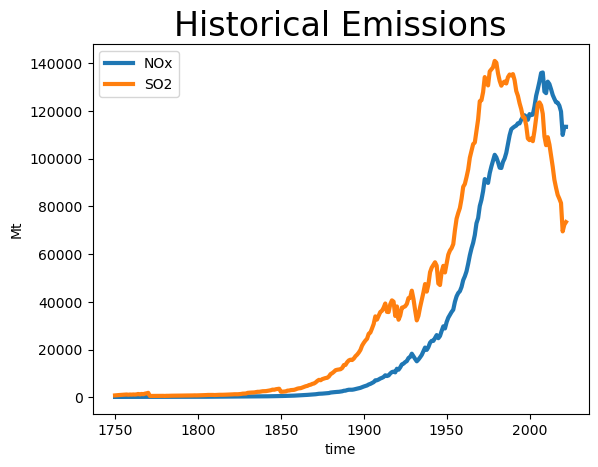

In [112]:
fig=plt.figure(figsize=default_figsize )
CEDS.get_global_by_sector("NOx").sum(dim="sector").plot(label="NOx",lw=3)
CEDS.get_global_by_sector("SO2").sum(dim="sector").plot(label="SO2",lw=3)
plt.title("Historical Emissions",fontsize=24)
plt.ylabel("Mt")
plt.legend()
if for_talk:
    mplcyberpunk.make_lines_glow()
    mplcyberpunk.add_underglow()

    plt.savefig("../Presentations/histem.png")

## But cleaning the air does not necessarily mitigate climate change
Even as aerosol emissions have fallen, methane and CO2 emissions continue to rise.

Text(0, 0.5, 'Gt')

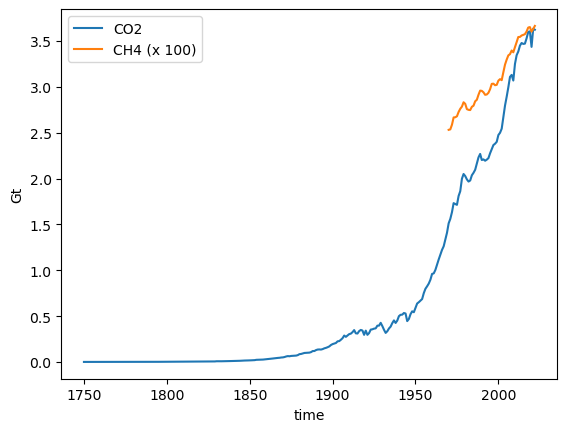

In [114]:
fig=plt.figure(figsize=default_figsize )
(1.e-7*CEDS.get_global_by_sector("CO2").sum(dim="sector")).plot(label="CO2")
(1e-5*CEDS.get_global_by_sector("CH4").sum(dim="sector")).plot(label="CH4 (x 100)")
plt.legend()
plt.ylabel("Gt")

## Future aerosol scenarios
We don't know what will happen to aerosol emissions in the future.  Nobody does.  But we can estimate the "worst-case" scenario of warming due to aerosol unmasking from standard reference scenarios used in the Coupled Model Intercomparison Project (CMIP, currently in Phase 7).  There are 3 standard CMIP7 scenarios we'll use for projection: 
* low
* medium
* high
  
Note that even in the high emissions scenario aerosols eventually flatline and decrease.

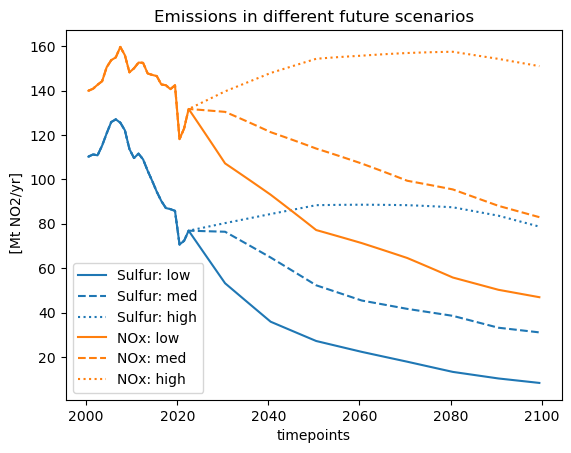

In [170]:
#fig=plt.figure(figsize=default_figsize)

lo=explorer.get_CMIP7_emissions("low",["Sulfur","NOx"]).sel(timepoints=slice(2000,2100))

med=explorer.get_CMIP7_emissions("medium-extension",["Sulfur","NOx"]).sel(timepoints=slice(2000,2100))


hi=explorer.get_CMIP7_emissions("high-extension",["Sulfur","NOx"]).sel(timepoints=slice(2000,2100))

lo.sel(specie="Sulfur").plot(color=cmap(0),ls="-",label="Sulfur: low")
med.sel(specie="Sulfur").plot(color=cmap(0),ls="--",label="Sulfur: med")
hi.sel(specie="Sulfur").plot(color=cmap(0),ls=":",label="Sulfur: high")

lo.sel(specie="NOx").plot(color=cmap(1),ls="-",label="NOx: low")
med.sel(specie="NOx").plot(color=cmap(1),ls="--",label="NOx: med")
hi.sel(specie="NOx").plot(color=cmap(1),ls=":",label="NOx: high")
plt.title("Emissions in different future scenarios")
plt.legend()

# Aerosol unmasking
As aerosols are cleaned up, greenhouse gas-induced warming is "unmasked".  Let's quantify a particular hypothetical ("clean air, no climate action"), in which SO2 emissions follow the trajectory in the "low" scenario while all other emissions follow the high trajectory.  We'll also compare it to a scenaro in which the aerosol-unmasked warming is partially offset by emergency brake action, in which methane emissions follow the low trajectory ("Clean air, emergency brake").

In [171]:
baseline_scenario="medium-extension"



balance_dicts={"Clean air, no climate action":
                   {"Sulfur":"low"},\
               "Dirty air, emergency brake":\
                   {"CH4":"low"},\
               "Clean air, emergency brake":\
                   {"CH4":"low",\
                    "Sulfur":"low"}}
              


We'll use `explorer.replacement_model` which lets us replace emissions in the baseline scenario with emissions from another reference scenario.

In [172]:
f=explorer.replacement_model(baseline_scenario,balance_dicts,lite=True,n_lite=10)

Running 40 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

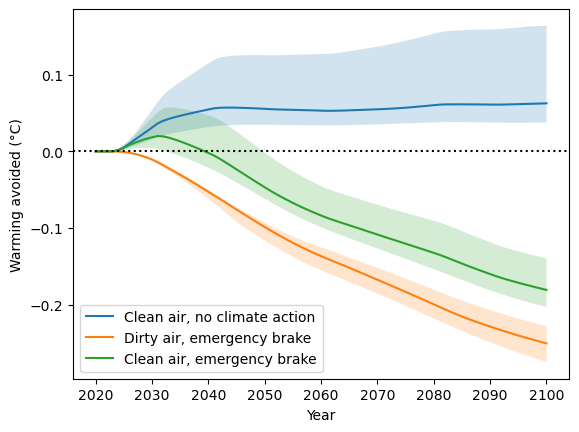

In [173]:
explorer.plot_T_diff(f)
plt.axhline(0,c="k",ls=":")

But SO2 is not the only aerosol.  Let's look at scenarios in which *all* the aerosols follow the low trajectory.

In [174]:
from utils import CEDS
arr=CEDS._CEDS_species
to_remove=["CH4","CO2"]
CEDS_aerosols= arr[~np.isin(arr, to_remove)]

In [175]:
aerosol_species=[CEDS.CEDS_name_to_FAIR(x) for x in CEDS_aerosols]
print("All aerosol species are:", aerosol_species)

All aerosol species are: ['BC', 'CO', 'N2O', 'NH3', 'VOC', 'NOx', 'OC', 'Sulfur']


In [176]:
low_aerosol_dict={}
for specie in aerosol_species:
    low_aerosol_dict[specie]="low"
highlow_dict={"low-allaer":low_aerosol_dict}
for specie in aerosol_species:
    highlow_dict[f"low-{specie}"]={specie:"low"}

In [177]:
baseline_scenario="constant"

In [181]:
compare_all_model=\
explorer.replacement_model(\
    baseline_scenario,highlow_dict,lite=False)

Running 8410 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

#### Aside: We can't count on black carbon as an emergency brake.
This is the impact of BC following the low scenario.  There is substantial uncertainty and we can't even guarantee that preventing BC emissions will lead to less warming.

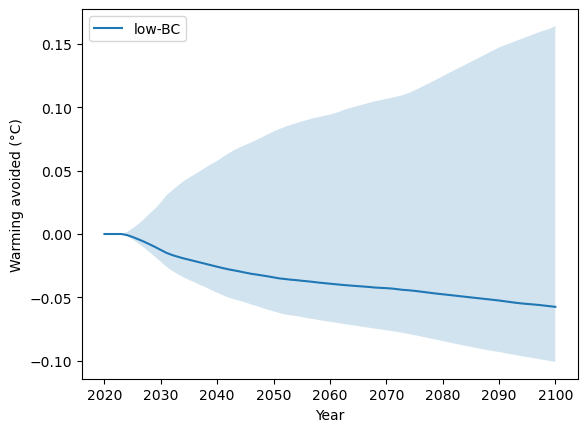

In [183]:
explorer.plot_T_diff(compare_all_model,scenarios=["low-BC"])

Zooming in on our two nasties: sulfuric acid and NOx.  Cutting SO2 emissions results in a rapid short-term warming which gradually slows down (because emissions fall more slowly after their initial rapid decline).  But cutting NOx leads to a more steady warming. 

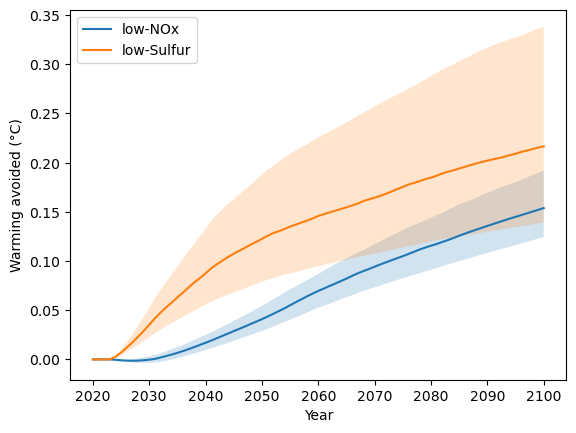

In [184]:
explorer.plot_T_diff(compare_all_model,scenarios=["low-NOx","low-Sulfur"])

The huge warming effect from NOx is because this decreases the abundance of OH radicals in the atmosphere, which causes the lifetime of methane to increase.

***nerd aside*** 

Check this- let's turn off the interactions between chemical species and the CH4 lifetime.

Setting ```CH4_lifetime_effects=False``` sets the ```ch4_lifetime_chemical_sensitivity``` parameter to 0 for NOx, CO, and VOC.

In [154]:
no_methane_interactions=explorer.replacement_model\
(baseline_scenario,highlow_dict,lite=True,\
 n_lite=100,CH4_lifetime_effects=False)

Running 1000 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

And, as expected, the warming due to NOx reductions is gone

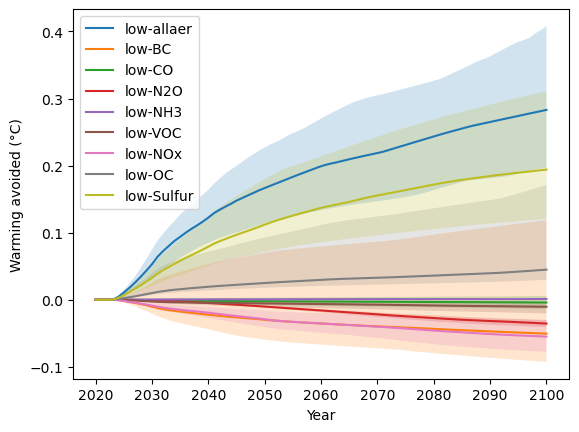

In [155]:
explorer.plot_T_diff(no_methane_interactions)

## How much methane reduction  do we need to abate the warming?
Let's put it all together: what would be the impact of cutting all aerosol emissions quickly.

In [156]:
aerosol_warming_T= compare_all_model.temperature.sel(layer=0)
aerosol_unmasking=aerosol_warming_T.sel(scenario="low-allaer")-aerosol_warming_T.sel(scenario=baseline_scenario)

Here's the warming we expect from maximum aerosol reductions.  The uncertainty is large- aerosols are very hard to model- but it looks on order of several tenths of a degree.  

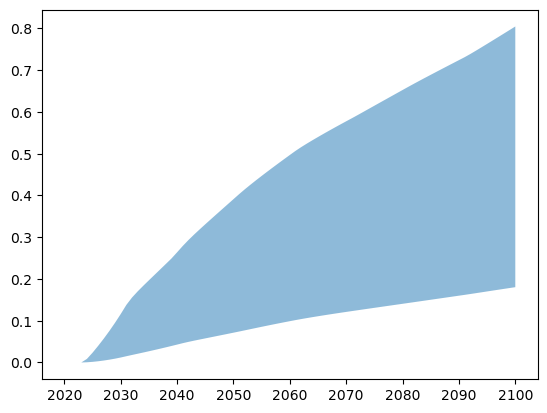

In [162]:
explorer.shadeplot(aerosol_unmasking.sel(timebounds=slice(2020,2100)))

In [159]:
aerosol_reductions=explorer.scenarios_to_emissions(baseline_scenario,{"low-allaer":low_aerosol_dict})

## Emergency brakes: theory to practice
Do we have enough tools at our disposal to counteract this unmasked warming?

Suppose overnight we implement the maxiumum achievable "Improve Diets" solution and the maximum achievable "Protect Peatlands: Tropical" solution

In [163]:
improve_diets=explorer.get_input("Improve Diets",\
              explorer.step_function,\
              units_adopted=explorer.achievable_adoption("Improve Diets", "high"),\
              implementation_start=2027,\
              land=True,\
              function_kwargs={},\
             scenario_name=None)

protect_peatlands_tropical = explorer.get_input("Protect Peatlands: Tropical",\
              explorer.rectangular_pulse,\
              units_adopted=explorer.achievable_adoption("Protect Peatlands: Tropical", "high"),\
              implementation_start=2027,\
              land=True,\
              function_kwargs={"duration":30},\
             scenario_name=None)
comparison_dict=aerosol_reductions|improve_diets|protect_peatlands_tropical

In [164]:
def combine_baseline_and_solutions(comparison_dict, baseline_scenario, solutions):
    """
    Combine a baseline (eg  aerosol reduction)  scenario with one or more solutions.

    Returns a dict with keys "{baseline_scenario}+{solution}" (one per
    entry in `solutions`) plus "{baseline_reduction_scenario}+all_solutions",
    each mapping specie -> summed timeseries.
    """
    def combined_species(keys):
        species = set().union(*(comparison_dict[k].keys() for k in keys))
        return {specie: sum(comparison_dict[k].get(specie, 0.0) for k in keys) for specie in species}

    combined = {
        f"{baseline_scenario}+{sln}": combined_species([baseline_scenario, sln])
        for sln in solutions
    }
    combined[f"{baseline_scenario}+all_solutions"] = combined_species([baseline_scenario, *solutions])
    return combined

aerosol_reduction_scenario = "low-allaer"
solution_keys = ["Improve Diets", "Protect Peatlands: Tropical"]
comparison_dict.update(combine_baseline_and_solutions(comparison_dict, aerosol_reduction_scenario, solution_keys))

In [165]:
idmodel=explorer.drawdown_model(baseline_scenario,comparison_dict,lite=True)

Running 70 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

# Can we mitigate warming by improving our diets?
## What about by protecting peatland?
No, we'd need to eat 10x less beef than the max solution

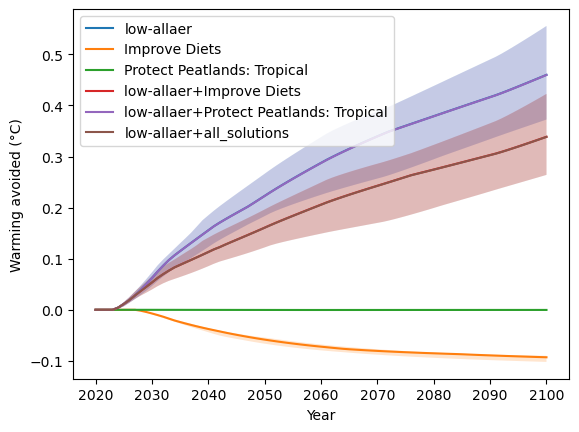

In [166]:
explorer.plot_T_diff(idmodel)